# 🍕 Food Detection avec YOLOv8
**Dataset :** [Bassou-Mou/food-detection](https://github.com/Bassou-Mou/food-detection)  
**Classes :** pizza, sandwich, pasta, hotdog  
**Modèle :** YOLOv8s  
**Runtime :** Google Colab T4 GPU

---
⚠️ **Avant de commencer :** Active le GPU → `Runtime > Change runtime type > T4 GPU`

## 1️⃣ Vérification du GPU

In [1]:
import torch
print('✅ GPU disponible :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('🎮 GPU :', torch.cuda.get_device_name(0))
else:
    print('❌ Pas de GPU — va dans Runtime > Change runtime type > T4 GPU')

✅ GPU disponible : True
🎮 GPU : Tesla T4


## 2️⃣ Installation de YOLOv8

In [2]:
!pip install ultralytics -q
from ultralytics import YOLO
print('✅ Ultralytics installé')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics installé


## 3️⃣ Cloner le dataset depuis GitHub

In [3]:
import os

!git clone https://github.com/Bassou-Mou/food-detection.git

# Vérifier la structure
print('\n📁 Structure du repo :')
for root, dirs, files in os.walk('/content/food-detection'):
    depth = root.replace('/content/food-detection', '').count(os.sep)
    if depth < 3:
        indent = '  ' * depth
        print(f'{indent}📂 {os.path.basename(root)}/')
        if depth < 2:
            for f in files[:5]:
                print(f'{indent}  📄 {f}')

Cloning into 'food-detection'...
remote: Enumerating objects: 4993, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 4993 (delta 0), reused 4 (delta 0), pack-reused 4988 (from 2)
Receiving objects: 100% (4993/4993), 345.95 MiB | 29.70 MiB/s, done.
Resolving deltas: 100% (251/251), done.
Updating files: 100% (3319/3319), done.

📁 Structure du repo :
📂 food-detection/
  📂 dataset/
    📄 data.yaml
    📂 images/
    📂 labels/
  📂 .git/
    📄 HEAD
    📄 config
    📄 index
    📄 description
    📄 packed-refs
    📂 logs/
    📂 info/
    📂 branches/
    📂 hooks/
    📂 objects/
    📂 refs/
  📂 scripts/
    📄 augmentation.py
    📄 scraper.py
    📄 download_images.py
    📄 collect_url.js
    📄 renommer_images.py


## 4️⃣ Créer le fichier data.yaml

In [4]:
# Le dataset suit la structure :
# food-detection/
#   dataset/
#     images/train  val  test
#     labels/train  val  test

DATA_YAML = '/content/food-detection/dataset/data.yaml'

yaml_content = """path: /content/food-detection/dataset
train: images/train
val: images/val
test: images/test

nc: 4
names:
  0: pizza
  1: sandwich
  2: pasta
  3: hotdog
"""

with open(DATA_YAML, 'w') as f:
    f.write(yaml_content)

print('✅ data.yaml créé :')
print(yaml_content)

# Vérifier que les dossiers images/labels existent
import os
BASE = '/content/food-detection/dataset'
for split in ['train', 'val', 'test']:
    img_dir = f'{BASE}/images/{split}'
    lbl_dir = f'{BASE}/labels/{split}'
    n_img = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    n_lbl = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0
    print(f'  {split:6s} → {n_img} images | {n_lbl} labels')

✅ data.yaml créé :
path: /content/food-detection/dataset
train: images/train
val: images/val
test: images/test

nc: 4
names:
  0: pizza
  1: sandwich
  2: pasta
  3: hotdog

  train  → 4 images | 4 labels
  val    → 4 images | 4 labels
  test   → 4 images | 4 labels


## 5️⃣ Visualiser quelques images du dataset

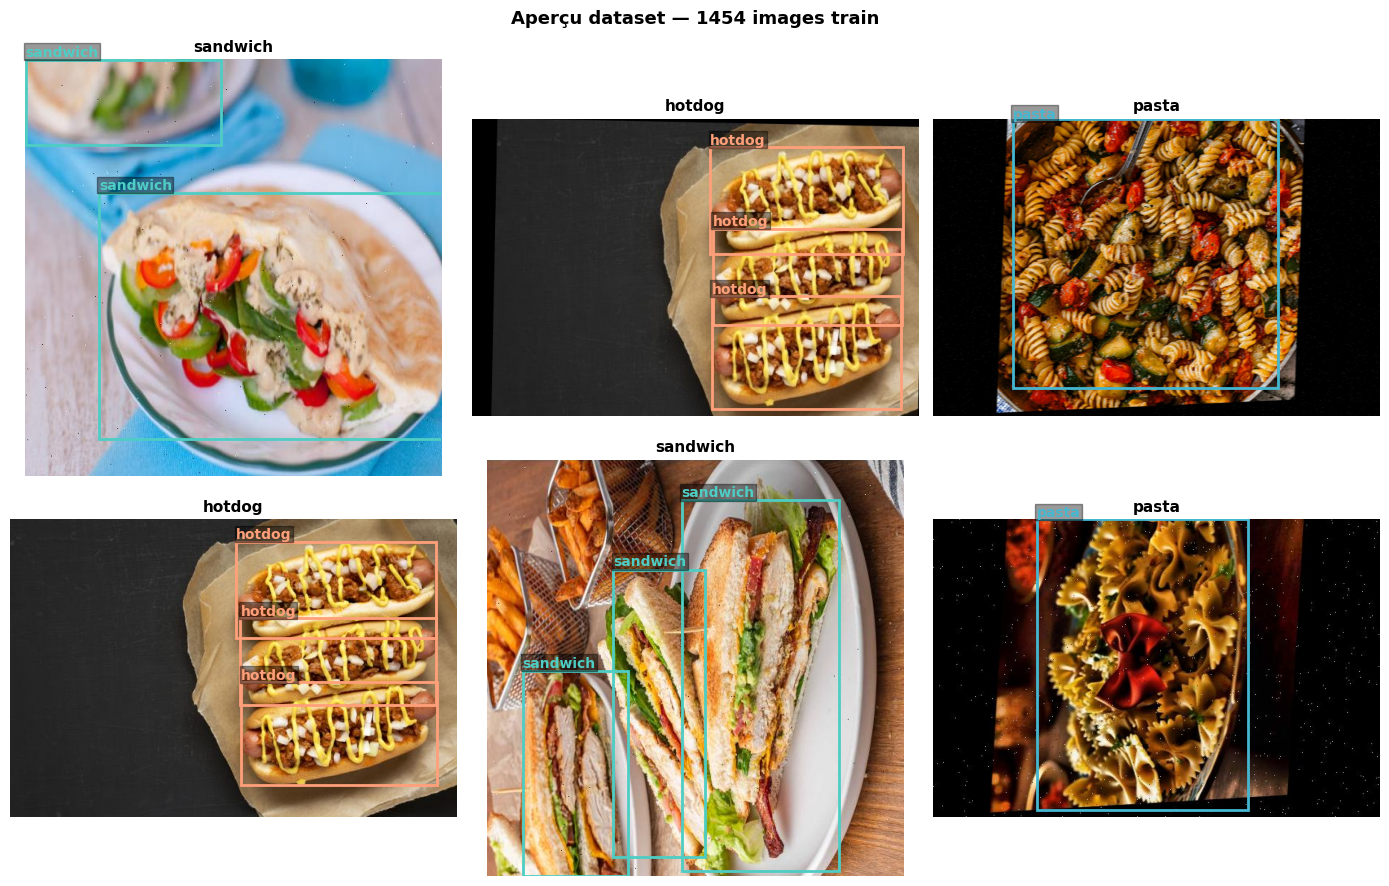

In [9]:
import random, glob, os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches

BASE = '/content/food-detection/dataset'
CLASSES = ['pizza', 'sandwich', 'pasta', 'hotdog']
COLORS  = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

images = glob.glob(f'{BASE}/images/train/**/*.jpg', recursive=True) + \
         glob.glob(f'{BASE}/images/train/**/*.png', recursive=True)

sample = random.sample(images, min(6, len(images)))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, img_path in zip(axes.flatten(), sample):
    img = mpimg.imread(img_path)
    h, w = img.shape[:2]
    ax.imshow(img)

    # Construire le chemin label : images/train/pizza/x.jpg -> labels/train/pizza/x.txt
    lbl_path = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'

    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls, xc, yc, bw, bh = int(parts[0]), *map(float, parts[1:])
                    x = (xc - bw/2) * w
                    y = (yc - bh/2) * h
                    color = COLORS[cls % 4]
                    rect = patches.Rectangle((x, y), bw*w, bh*h,
                                             linewidth=2, edgecolor=color, facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x, y - 5, CLASSES[cls], color=color,
                            fontsize=10, fontweight='bold',
                            bbox=dict(facecolor='black', alpha=0.4, pad=1))
    else:
        ax.set_xlabel('⚠️ label manquant', color='red')

    cls_name = os.path.basename(os.path.dirname(img_path))
    ax.set_title(cls_name, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle(f'Aperçu dataset — {len(images)} images train', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6️⃣ Entraînement YOLOv8
> ⏱️ Durée estimée : **30-45 min** sur T4  
> `patience=15` arrête l'entraînement automatiquement si le modèle ne s'améliore plus

In [10]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')  # small : bon compromis vitesse/précision

results = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    patience=15,
    save=True,
    project='/content/runs',
    name='food_detector',
    exist_ok=True,
    plots=True,
    verbose=True
)

print('\n✅ Entraînement terminé !')
print('📦 Modèle sauvegardé dans : /content/runs/food_detector/weights/best.pt')

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/food-detection/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=food_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

## 7️⃣ Évaluation — métriques finales

In [11]:
best_model = YOLO('/content/runs/food_detector/weights/best.pt')

metrics = best_model.val(data=DATA_YAML)

print('\n📊 Résultats globaux :')
print(f'  mAP50        : {metrics.box.map50:.4f}  (> 0.8 = bon, > 0.9 = excellent)')
print(f'  mAP50-95     : {metrics.box.map:.4f}')
print(f'  Précision    : {metrics.box.mp:.4f}')
print(f'  Rappel       : {metrics.box.mr:.4f}')

print('\n📊 mAP50 par classe :')
CLASSES = ['pizza', 'sandwich', 'pasta', 'hotdog']
for i, (cls, ap) in enumerate(zip(CLASSES, metrics.box.ap50)):
    bar = '█' * int(ap * 20)
    print(f'  {cls:10s} : {bar:<20s} {ap:.4f}')

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1835.2±1269.1 MB/s, size: 223.3 KB)
val: Scanning /content/food-detection/dataset/labels/val/hotdog.cache... 109 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 109/109 32.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 2, len(boxes) = 167. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.9it/s 3.7s
                   all        109        167      0.846      0.873      0.901      0.682
                 pizza         39         47      0.804      0.915      0.894      0.754
              sandwich  

## 8️⃣ Courbes d'entraînement

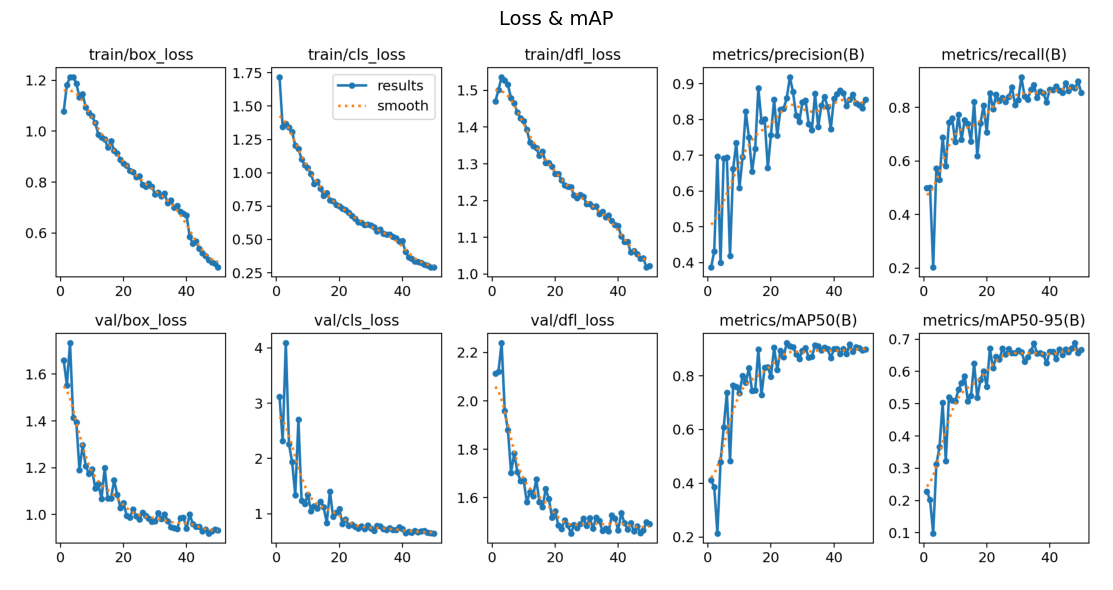

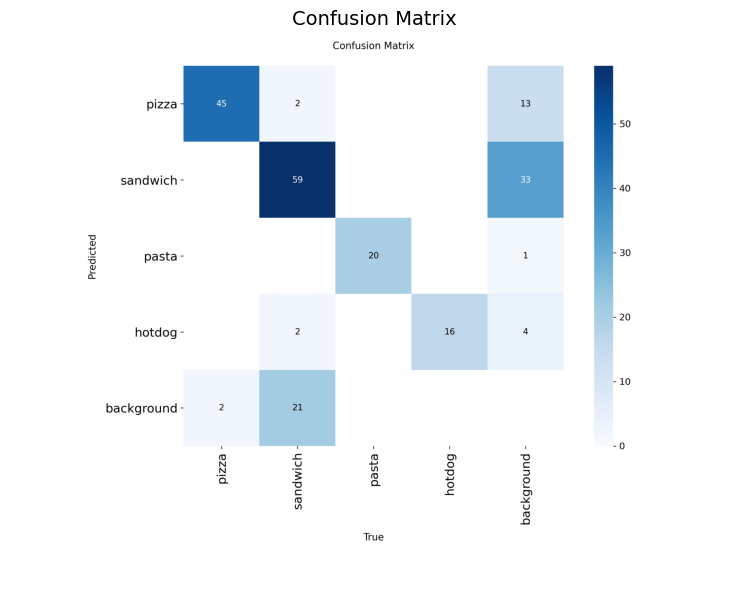

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plots = [
    ('/content/runs/food_detector/results.png',          'Loss & mAP'),
    ('/content/runs/food_detector/confusion_matrix.png', 'Confusion Matrix'),
    ('/content/runs/food_detector/PR_curve.png',         'Precision-Recall Curve'),
]

for path, title in plots:
    if os.path.exists(path):
        plt.figure(figsize=(14, 6))
        plt.imshow(mpimg.imread(path))
        plt.title(title, fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

## 9️⃣ Test sur le set de test

✅ 91 images test trouvées


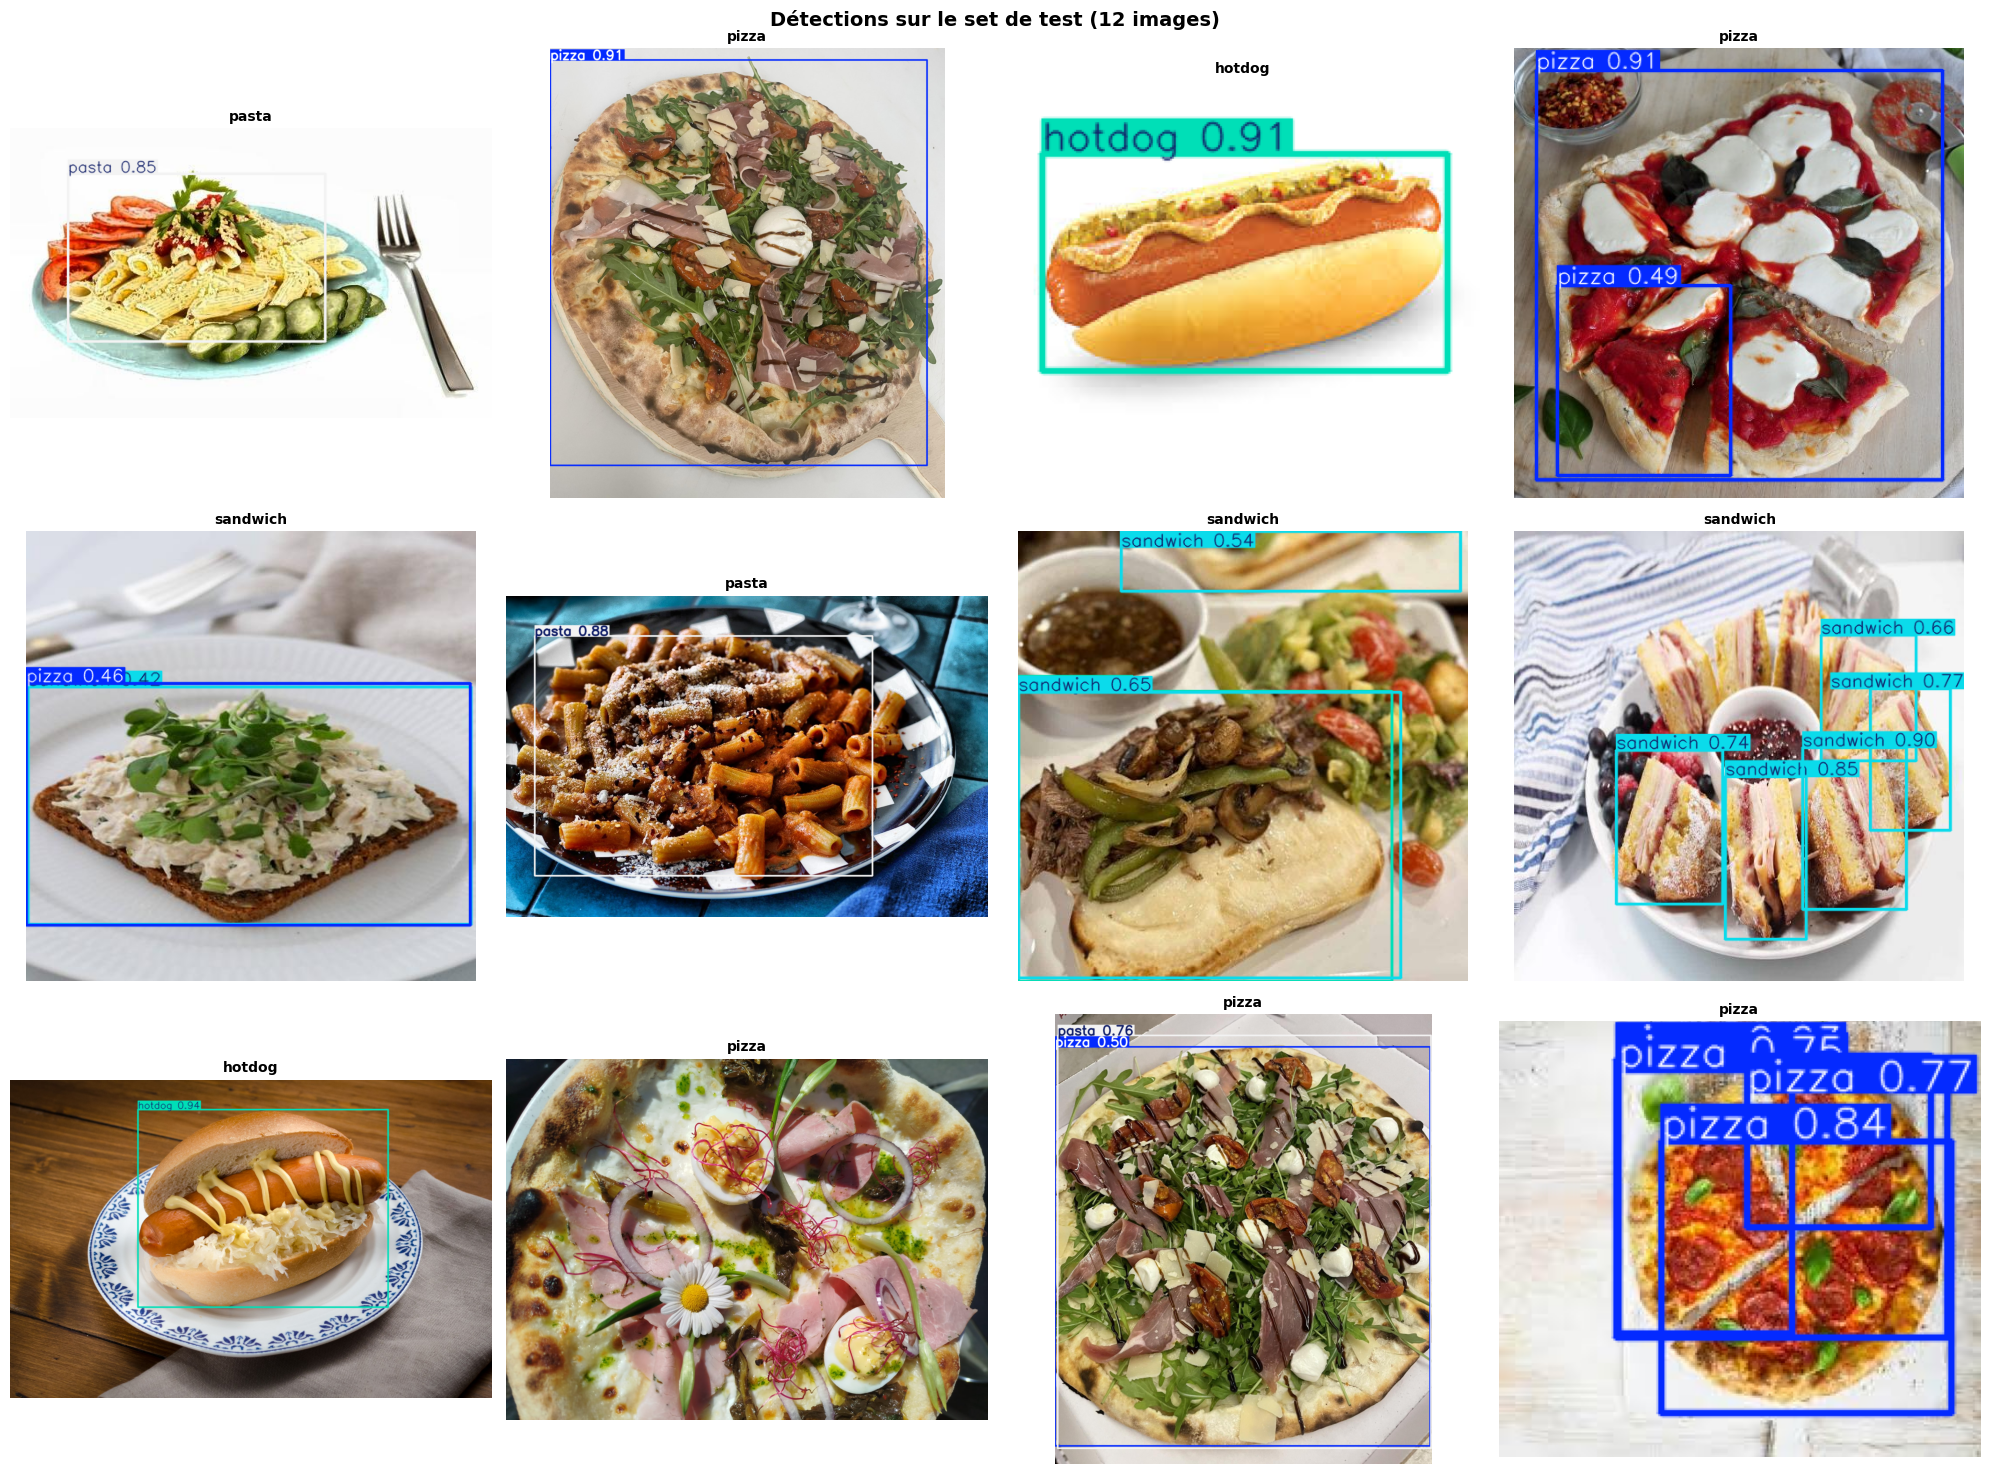

In [15]:
import random, glob, os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

BASE = '/content/food-detection/dataset'

test_images = glob.glob(f'{BASE}/images/test/**/*.jpg', recursive=True) + \
              glob.glob(f'{BASE}/images/test/**/*.png', recursive=True)

print(f'✅ {len(test_images)} images test trouvées')

sample = random.sample(test_images, min(12, len(test_images)))

fig, axes = plt.subplots(3, 4, figsize=(20, 15))

for ax, img_path in zip(axes.flatten(), sample):
    results = best_model.predict(img_path, conf=0.4, verbose=False)
    result_img = results[0].plot()
    ax.imshow(result_img[:, :, ::-1])
    cls_name = os.path.basename(os.path.dirname(img_path))
    ax.set_title(cls_name, fontsize=10, fontweight='bold')
    ax.axis('off')

# Cacher les axes vides si moins de 12 images
for ax in axes.flatten()[len(sample):]:
    ax.axis('off')

plt.suptitle(f'Détections sur le set de test ({len(sample)} images)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔟 Télécharger le modèle entraîné

In [16]:
from google.colab import files
import os

model_path = '/content/runs/food_detector/weights/best.pt'
print(f'📦 Taille du modèle : {os.path.getsize(model_path) / 1e6:.1f} MB')
files.download(model_path)
print('✅ Téléchargement lancé !')

📦 Taille du modèle : 22.5 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Téléchargement lancé !


## 💾 (Optionnel) Sauvegarde sur Google Drive
> Recommandé pour ne pas perdre le modèle si Colab se déconnecte

In [17]:
from google.colab import drive
import shutil

drive.mount('/content/drive')

dest = '/content/drive/MyDrive/food_detector_best.pt'
shutil.copy('/content/runs/food_detector/weights/best.pt', dest)
print('✅ Modèle sauvegardé sur Drive :', dest)

Mounted at /content/drive
✅ Modèle sauvegardé sur Drive : /content/drive/MyDrive/food_detector_best.pt
